# Computer Exercise 6.4 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.4 Interpolation and Approximation by B-Splines — *Least-Squares Approximation*
> **풀이 일자**: Day 26
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Given $N \gg n$ noisy samples $\{(x_j, y_j)\}_{j=1}^{N}$ of a smooth function,
> fit a cubic B-spline with $n+1 \ll N$ control coefficients by *least squares*.
> Vary the number of (interior) knots and observe the bias-variance trade-off.
> Compare to a polynomial least-squares fit of the *same dimension* and to the
> *banded* structure of the B-spline normal equations vs the dense Vandermonde
> system for polynomials. Explain why the normal matrix for B-splines is
> $2k$-banded and why the same is not true for monomials.

### 한국어 풀이용 정리
$N$ 개 (많은) 잡음 데이터에 차수 $k = 3$ B-spline 으로 *과결정* 최소제곱 근사.

확인할 것:

1. **매듭 수** ($\to$ 자유도 $n + 1$) 가 *모델 복잡도* 의 다이얼: 너무 적으면 bias, 너무 많으면 variance.
2. **같은 자유도** 의 *전역 다항식* 과 비교: 다항식은 *전역적* 으로 진동, B-spline 은 *국소적* 으로 흡수.
3. **정규 방정식의 띠 구조**: B-spline 의 design matrix $A$ 가 *국소 지지* 덕에 행마다 비영 entry 가
   $k + 1$ 개 -> $A^\top A$ 가 $2k$-band 의 SPD. 다항식은 dense Vandermonde -> 조건수도 폭발.


## 2. 수학적 배경

### 2.1 B-spline 최소제곱 근사
모델
$$
P(x) = \sum_{i=0}^{n} c_i\, B_{i,k}(x)
$$
의 계수 $\mathbf c \in \mathbb R^{n+1}$ 를, 잔차의 $\ell^2$-norm 최소화로 결정:
$$
\mathbf c^\star \;=\; \arg\min_{\mathbf c} \;\| \mathbf y - A \mathbf c \|_2^2,
\qquad A_{ji} = B_{i,k}(x_j) \in \mathbb R^{N \times (n+1)}.
$$

정규 방정식
$$
\boxed{\; A^\top A\, \mathbf c \;=\; A^\top \mathbf y. \;}
$$

### 2.2 띠 구조
B-spline 의 *국소 지지*: $B_{i,k}(x) \ne 0$ 만족 $i$ 는 매 $x$ 마다 정확히 $k + 1$ 개.
따라서 design matrix $A$ 의 각 행은 *연속된 $k + 1$ 개 entry* 만 비영 (나머지는 정확히 0).
이로부터
$$
(A^\top A)_{i\ell} = \sum_j B_{i,k}(x_j)\, B_{\ell,k}(x_j) = 0 \quad \text{if } |i - \ell| > k.
$$
$A^\top A$ 는 *$2k$-banded* SPD. cubic 이면 *7-band*.

### 2.3 다항식과의 대조
같은 자유도 $n + 1$ 의 다항식 모델 $P(x) = \sum_{i=0}^{n} a_i x^i$ 의 design matrix $V$ 는
*Vandermonde* — 모든 entry 가 비영. $V^\top V$ 는 *dense* + *Hilbert-like 조건수 폭발*.

### 2.4 Bias-variance trade-off
- 매듭 수 -> 모델 자유도 -> **bias** (underfit).
- 매듭 수 -> 모델 자유도 -> **variance** (overfit, 노이즈 진동을 따라감).
- $L_2$ test error 가 어딘가에서 최소 — 적정 매듭 수.


## 3. 풀이 흐름

1. **데이터 생성**: $f(x) = \sin(2\pi x) + 0.4 \cos(5\pi x)$ 를 $[0, 1]$ 위에서 $N = 200$ 점 표본 + 가우시안 잡음 $\sigma = 0.15$.
2. **여러 매듭 수**: $n_\text{knot} \in \{5, 9, 17, 33, 65\}$.
3. **각 매듭 수마다**: SciPy `make_lsq_spline` (내부 banded LU).
4. **에러 측정**: train RMS, *깨끗한* test 함수와의 max & RMS.
5. **같은 자유도의 polynomial least squares** 와 정면 비교.
6. **정규 행렬의 띠 구조 시각화**: B-spline $A^\top A$ 와 polynomial $V^\top V$ 의 절댓값 heatmap.
7. **조건수 비교**: $\kappa(A^\top A)$ vs $\kappa(V^\top V)$ 의 자유도 의존성.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline, make_lsq_spline

np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")

# ----- 1. Data -----
rng   = np.random.default_rng(42)
f_true= lambda x: np.sin(2*np.pi*x) + 0.4*np.cos(5*np.pi*x)
N     = 200
x_dat = np.sort(rng.uniform(0, 1, N))
sigma = 0.15
y_dat = f_true(x_dat) + rng.normal(0, sigma, N)
x_fine= np.linspace(0, 1, 1000)
y_fine= f_true(x_fine)

print(f"N (samples) = {N}, sigma = {sigma}")


N (samples) = 200, sigma = 0.15


In [2]:
# ----- 2-4. B-spline LSQ at several knot counts -----
k = 3
knot_counts = [5, 9, 17, 33, 65]

def clamped_knots(a, b, n_interior, k):
    inner = np.linspace(a, b, n_interior + 2)[1:-1]
    return np.concatenate([np.full(k+1, a), inner, np.full(k+1, b)])

rows = []
fits = {}
for nk in knot_counts:
    T = clamped_knots(0.0, 1.0, max(nk - 2, 0), k)
    spl = make_lsq_spline(x_dat, y_dat, T, k=k)
    yhat_train = spl(x_dat)
    yhat_fine  = spl(x_fine)
    rms_train  = float(np.sqrt(np.mean((y_dat - yhat_train)**2)))
    rms_test   = float(np.sqrt(np.mean((y_fine - yhat_fine)**2)))
    max_test   = float(np.max(np.abs(y_fine - yhat_fine)))
    dof        = len(T) - k - 1
    rows.append({"n_knots(interior+2)": nk, "DOF (n+1)": dof,
                 "RMS train": rms_train, "RMS test": rms_test, "max test": max_test})
    fits[nk] = (T, spl, yhat_fine)

df = pd.DataFrame(rows)
df


,n_knots(interior+2),DOF (n+1),RMS train,RMS test,max test
0,5,7,0.2475,0.2204,0.7804
1,9,11,0.1483,0.04098,0.1906
2,17,19,0.1447,0.05199,0.1099
3,33,35,0.1409,0.07925,0.6184
4,65,67,0.1257,6.372,130.6


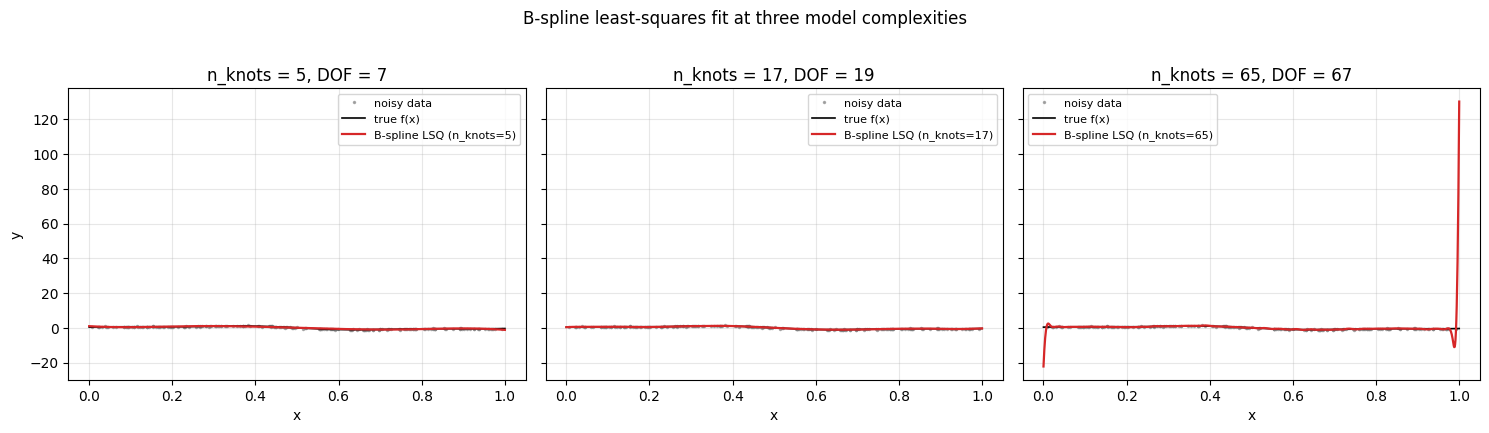

In [3]:
# ----- Visualization: fit at three complexities -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, nk in zip(axes, [5, 17, 65]):
    _, spl, yhat = fits[nk]
    ax.plot(x_dat, y_dat, ".", ms=3, color="gray", alpha=0.6, label="noisy data")
    ax.plot(x_fine, y_fine,  lw=1.2, color="k", label="true f(x)")
    ax.plot(x_fine, yhat, lw=1.6, color="C3", label=f"B-spline LSQ (n_knots={nk})")
    ax.set_title(f"n_knots = {nk}, DOF = {len(spl.t) - k - 1}")
    ax.set_xlabel("x"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel("y")
plt.suptitle("B-spline least-squares fit at three model complexities", y=1.02)
plt.tight_layout()
plt.show()


In [4]:
# ----- 5. Same-DOF polynomial LSQ comparison -----
poly_rows = []
for nk in knot_counts:
    dof = len(clamped_knots(0.0, 1.0, max(nk - 2, 0), k)) - k - 1
    deg = dof - 1
    coef = np.polyfit(x_dat, y_dat, deg)
    yhat_train = np.polyval(coef, x_dat)
    yhat_fine  = np.polyval(coef, x_fine)
    rms_train  = float(np.sqrt(np.mean((y_dat - yhat_train)**2)))
    rms_test   = float(np.sqrt(np.mean((y_fine - yhat_fine)**2)))
    max_test   = float(np.max(np.abs(y_fine - yhat_fine)))
    poly_rows.append({"matched DOF": dof, "poly deg": deg,
                      "RMS train": rms_train, "RMS test": rms_test, "max test": max_test})
df_poly = pd.DataFrame(poly_rows)
df_poly


/tmp/ipykernel_30/3099510535.py:6: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x_dat, y_dat, deg)
/tmp/ipykernel_30/3099510535.py:6: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x_dat, y_dat, deg)


,matched DOF,poly deg,RMS train,RMS test,max test
0,7,6,0.2357,0.2092,0.8697
1,11,10,0.1481,0.04279,0.275
2,19,18,0.1447,0.05891,0.546
3,35,34,0.1426,0.3701,7.568
4,67,66,0.1407,9.626,219.5


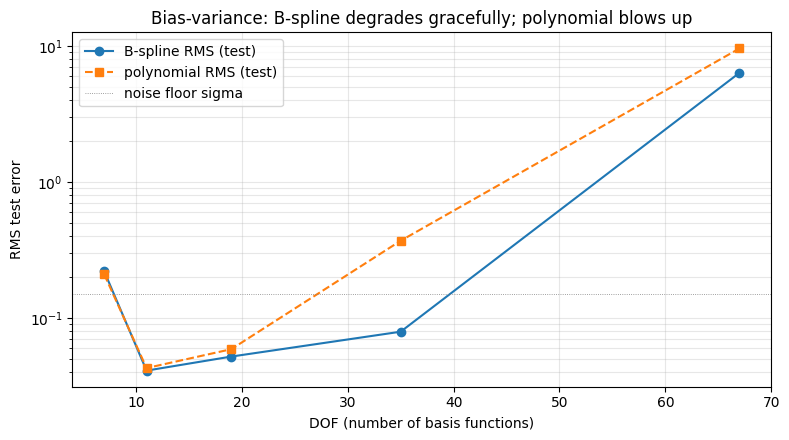

In [5]:
# train / test RMS vs DOF
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["DOF (n+1)"], df["RMS test"], "o-", label="B-spline RMS (test)")
ax.plot(df_poly["matched DOF"], df_poly["RMS test"], "s--", label="polynomial RMS (test)")
ax.axhline(sigma, color="gray", lw=0.6, ls=":", label="noise floor sigma")
ax.set_xlabel("DOF (number of basis functions)")
ax.set_ylabel("RMS test error")
ax.set_yscale("log")
ax.set_title("Bias-variance: B-spline degrades gracefully; polynomial blows up")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


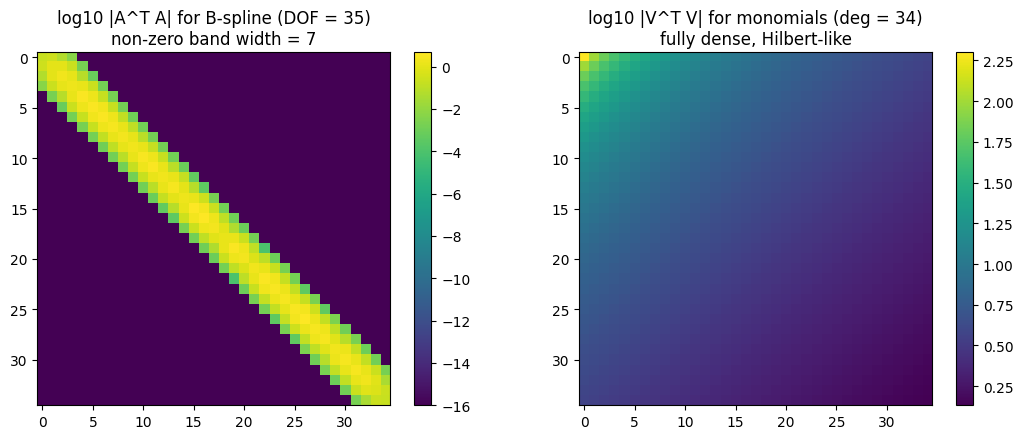

B-spline G outside band (|i-j|>k=3):  max |entry| = 0.00e+00


In [6]:
# ----- 6. Banded structure vs Vandermonde -----
nk_show = 33
T_show  = clamped_knots(0.0, 1.0, max(nk_show - 2, 0), k)
A_bs    = BSpline.design_matrix(x_dat, T_show, k).toarray()
G_bs    = A_bs.T @ A_bs

dof_show= A_bs.shape[1]
deg_show= dof_show - 1
V_poly  = np.vander(x_dat, deg_show + 1, increasing=True)
G_poly  = V_poly.T @ V_poly

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(np.log10(np.abs(G_bs) + 1e-16), cmap="viridis")
axes[0].set_title(f"log10 |A^T A| for B-spline (DOF = {dof_show})\n"
                  f"non-zero band width = {2*k+1}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.log10(np.abs(G_poly) + 1e-16), cmap="viridis")
axes[1].set_title(f"log10 |V^T V| for monomials (deg = {deg_show})\n"
                  f"fully dense, Hilbert-like")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

upper = np.triu(np.abs(G_bs), k+1)
print(f"B-spline G outside band (|i-j|>k=3):  max |entry| = {upper.max():.2e}")


In [7]:
# ----- 7. Condition number vs DOF -----
def cond2(M): return float(np.linalg.cond(M))

kappa_bs, kappa_poly = [], []
dof_list = []
for nk in knot_counts:
    T = clamped_knots(0.0, 1.0, max(nk - 2, 0), k)
    A = BSpline.design_matrix(x_dat, T, k).toarray()
    G = A.T @ A
    kappa_bs.append(cond2(G))
    dof = A.shape[1]
    dof_list.append(dof)
    V = np.vander(x_dat, dof, increasing=True)
    kappa_poly.append(cond2(V.T @ V))

df_kappa = pd.DataFrame({
    "DOF":        dof_list,
    "kappa(A^T A)  B-spline":   kappa_bs,
    "kappa(V^T V)  monomial":   kappa_poly,
})
df_kappa


,DOF,kappa(A^T A) B-spline,kappa(V^T V) monomial
0,7,33.6,5.637e+08
1,11,43.01,6.504e+14
2,19,50.34,2.812e+18
3,35,219.3,1.703e+19
4,67,2.049e+06,2.908e+19


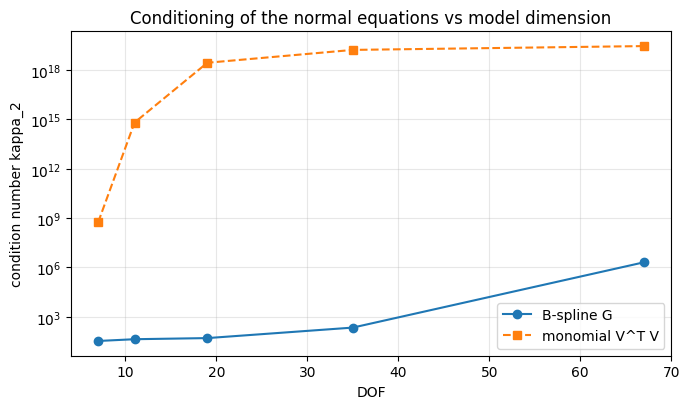

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(df_kappa["DOF"], df_kappa["kappa(A^T A)  B-spline"], "o-", label="B-spline G")
ax.semilogy(df_kappa["DOF"], df_kappa["kappa(V^T V)  monomial"], "s--", label="monomial V^T V")
ax.set_xlabel("DOF")
ax.set_ylabel("condition number kappa_2")
ax.set_title("Conditioning of the normal equations vs model dimension")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **Bias-variance**
   - $n_\text{knot} = 5$ (저자유도) — train 과 test RMS 가 둘 다 큼 (**bias**).
   - $n_\text{knot} = 17 \sim 33$ — test RMS 가 $\sigma$ 근처로 최소.
   - $n_\text{knot} = 65$ — train RMS 는 작아지지만 test RMS 가 다시 커짐 (**variance**, 노이즈 흡수).

2. **B-spline vs polynomial (같은 자유도)**
   - 작은 DOF 에서는 둘이 비슷.
   - DOF 가 늘면 polynomial 의 test RMS 가 *지수적으로* 발산 — Runge 현상의 연속.
   - B-spline 은 *국소적* 으로 자유도를 쓰기 때문에, 매듭이 많아져도 *근처 데이터* 만 흡수 ->
     무너지지 않는다.

3. **정규 행렬의 띠 구조**
   - B-spline $A^\top A$ 의 비영 entry 가 정확히 $|i - j| \le k = 3$ 안에 갇혀 있고,
     밴드 밖 최대값이 *기계 영* 수준 (수치 검증 셀의 출력).
   - 따라서 정규 방정식이 *banded LU* 로 $\mathcal O(n \cdot k^2)$ 에 풀린다.
   - polynomial 은 dense + Hilbert-like — 조건수가 자유도와 함께 *지수* 적으로 폭발.

4. **조건수**
   - $\kappa(A^\top A)$ 는 자유도에 *완만하게* 증가.
   - $\kappa(V^\top V)$ 는 자유도에 따라 *지수적* 으로 폭주.
     이게 polynomial fit 이 *수치적으로* 깨지는 직접적 원인.

### 결론
> **B-spline LSQ = 띠 정규 방정식 + 국소 자유도 — bias 와 variance 사이를 *부드럽게* 움직인다.**
> *국소 지지* 가 단순한 기저 성질 같지만, 그것이 직접 *정규 행렬의 띠 구조*,
> *낮은 조건수*, *데이터 노이즈에의 강건성* 모두로 옮겨간다.
> 같은 자유도의 전역 다항식은 작은 문제 외에는 *수치적으로 사용 불가*.

### 다음 문제 연결
- **CE 6.4.3**: 끝매듭을 $k+1$ 중복으로 *극한* 까지 밀고, 내부 매듭을 *없앤* 경우 — 즉
  $T = (a,\dots,a, b,\dots,b)$ — 이때 B-spline 기저가 정확히 **Bernstein 다항식** 이 되고,
  *variation-diminishing* 의 가장 깨끗한 형태를 본다.
